In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# boston 데이터 세트 로드
bostonDF = pd.read_csv("BostonHousing.csv")

# boston 데이터 세트 DataFrame 변환
# bostonDF = pd.DataFrame(boston.data , columns = boston.feature_names)

# boston 데이터 세트의 target 배열은 주택 가격임. 이를 PRICE 칼럼으로 DataFrame에 추가함

bostonDF['price'] = bostonDF["medv"]
bostonDF.drop('medv', axis = 1, inplace = True)
print('Boston 데이터 세트 크기 :',bostonDF.shape)
bostonDF.head()

Boston 데이터 세트 크기 : (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [16]:
bostonDF = bostonDF.dropna()
bostonDF.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 501 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     501 non-null    float64
 1   zn       501 non-null    float64
 2   indus    501 non-null    float64
 3   chas     501 non-null    int64  
 4   nox      501 non-null    float64
 5   rm       501 non-null    float64
 6   age      501 non-null    float64
 7   dis      501 non-null    float64
 8   rad      501 non-null    int64  
 9   tax      501 non-null    int64  
 10  ptratio  501 non-null    float64
 11  b        501 non-null    float64
 12  lstat    501 non-null    float64
 13  price    501 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 58.7 KB


In [17]:
from matplotlib.figure import figaspect
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = bostonDF["price"]
x_data = bostonDF.drop(["price"], axis = 1, inplace = False)

x_train, x_test, y_train, y_test = train_test_split(x_data, y_target, test_size = 0.3, random_state = 156)

# 선형 회귀 OLS로 학습/예측/평가
lr = LinearRegression()
lr.fit(x_train, y_train)
y_preds = lr.predict(x_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print("MSE : {0:.3f}, RMSE : {1:.3F}".format(mse, rmse))
print("Variance score : {0:.3f}".format(r2_score(y_test, y_preds)))

MSE : 21.332, RMSE : 4.619
Variance score : 0.776


In [18]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. 인덱스 칼럼명에 유의
coef = pd.Series(data = np.round(lr.coef_, 1), index = x_data.columns)
coef.sort_values(ascending = False)

rm          3.4
chas        1.6
rad         0.3
indus       0.1
zn          0.0
age         0.0
tax        -0.0
b           0.0
crim       -0.1
lstat      -0.6
ptratio    -0.9
dis        -1.5
nox       -16.8
dtype: float64

In [19]:
from sklearn.model_selection import cross_val_score

y_target = bostonDF["price"]
x_data = bostonDF.drop(["price"], axis = 1, inplace = False)
lr = LinearRegression()

# cross_val_score()로 5폴드 세트로 MSE를 구한 뒤 이를 기반으로 다시 RMSE 구함
neg_mse_scores = cross_val_score(lr, x_data, y_target, scoring = "neg_mean_squared_error", cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring = "neg_mean_squared_error")로 반환된 값은 모두 음수
print(" 5 folds의 개별 Negative MSE scores :", np.round(neg_mse_scores, 2))
print(" 5 folds의 개별 RMSE scores :", np.round(rmse_scores, 2))
print(" 5 folds의 평균 RMSE : {0:.3f}".format(avg_rmse))

 5 folds의 개별 Negative MSE scores : [-12.03 -29.28 -32.23 -88.23 -33.17]
 5 folds의 개별 RMSE scores : [3.47 5.41 5.68 9.39 5.76]
 5 folds의 평균 RMSE : 5.942


## 릿지 회귀

In [20]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# alpha = 10으로 설정해 릿지 회귀 수행
ridge = Ridge(alpha=10)
neg_mean_scores = cross_val_score(ridge, x_data, y_target, scoring = "neg_mean_squared_error", cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
ave_rmse = np.mean(rmse_scores)
print(" 5 folds의 개별 Negative MSE scores :", np.round(neg_mse_scores, 3))
print(" 5 folds의 개별 RMSE scores :", np.round(rmse_scores, 3))
print(" 5 folds의 평균 RMSE :", np.round(ave_rmse, 3))

 5 folds의 개별 Negative MSE scores : [-12.03  -29.277 -32.233 -88.233 -33.166]
 5 folds의 개별 RMSE scores : [3.468 5.411 5.677 9.393 5.759]
 5 folds의 평균 RMSE : 5.942


In [21]:
# 릿지에 사용될 alpha 파라미터의 값을 정의
alphas = [0, 0.1, 1, 10, 100]

# alphas 리스트 값을 반복하면서 alpha에 따른 평균 rmse를 구함
for alpha in alphas:
    ridge = Ridge(alpha = alpha)

    # cross_val_score를 이용해 5 폴드의 평균 RMSE를 계산
    neg_mse_scores = cross_val_score(ridge, x_data, y_target, scoring = "neg_mean_squared_error", cv = 5)
    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
    print("alpha {0} 일 때 5 folds의 평균 RMSE : {1:.3f}".format(alpha, avg_rmse))

alpha 0 일 때 5 folds의 평균 RMSE : 5.942
alpha 0.1 일 때 5 folds의 평균 RMSE : 5.903
alpha 1 일 때 5 folds의 평균 RMSE : 5.769
alpha 10 일 때 5 folds의 평균 RMSE : 5.624
alpha 100 일 때 5 folds의 평균 RMSE : 5.398


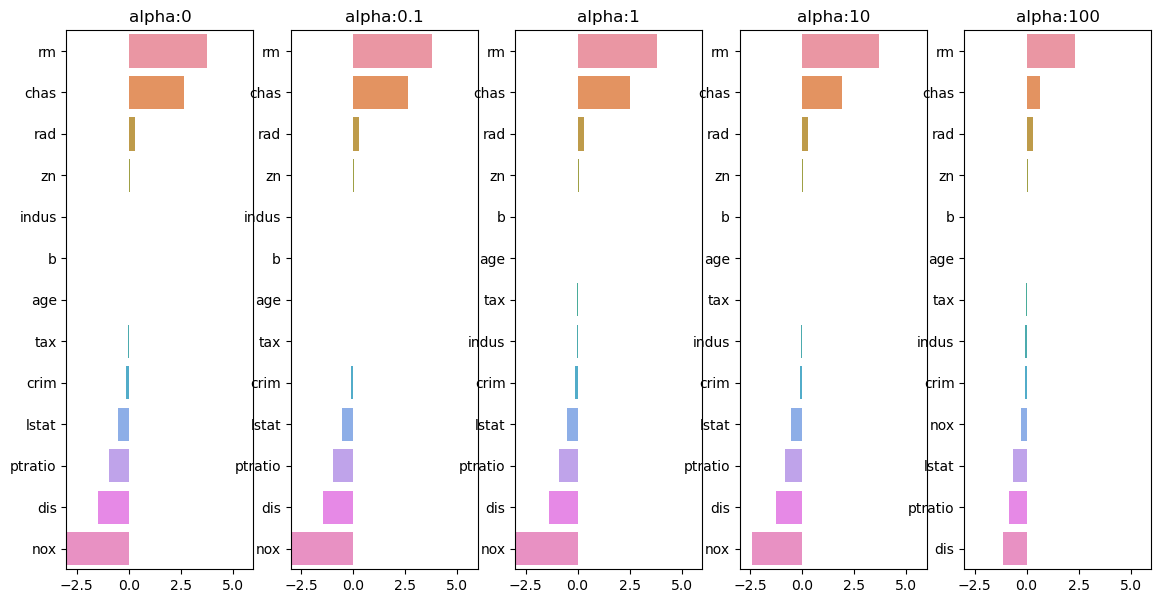

In [13]:
# 각 alpha에 따른 회귀 계수 값을 시각화하기 위해 5개의 열로 된 맷플롯립 축 생성
fig, axs = plt.subplots(figsize = (14, 7), nrows = 1, ncols = 5)
# 각 alpha에 따른 회귀 계수 값을 데이터로 저장하기 위한 DataFrame 생성
coeff_df = pd.DataFrame()

# alphas 리스트 값을 차례로 입력해 회귀 계수 값 기가화 및 데이터 저장. pos는 axis의 위치 지정
for pos, alpha in enumerate(alphas):
    ridge = Ridge(alpha = alpha)
    ridge.fit(x_data, y_target)
    # alpha에 따른 피처별로 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가
    coeff = pd.Series(data = ridge.coef_, index = x_data.columns)
    colname = 'alpha:' + str(alpha)
    coeff_df[colname] = coeff
    # 막대 그래프로 각 alpha 값에서의 회귀 계수를 시각화, 회귀 계수값이 높은 순으로 표현
    coeff = coeff.sort_values(ascending = False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-3, 6)
    sns.barplot(x = coeff.values, y = coeff.index, ax = axs[pos])

# for 문 바깥에서 맷플롯ㄹ비의 show 호출 및 alpha에 따른 피처별 회귀 계수를 DataFrame으로 표시
plt.show()

In [22]:
ridge_alphas = [0,0.1,1,10,100]
sort_column = 'alpha:' + str(ridge_alphas[0])
coeff_df.sort_values(by = sort_column, ascending = False)
     

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
rm,3.781141,3.790072,3.828795,3.680888,2.317671
chas,2.667336,2.650597,2.533137,1.936759,0.633636
rad,0.305855,0.303311,0.289906,0.279364,0.315210
zn,0.045483,0.045644,0.046571,0.048769,0.053612
indus,0.014017,0.009462,-0.015283,-0.049456,-0.060326
b,0.009321,0.009379,0.009691,0.010061,0.009412
age,0.001969,0.000980,-0.004306,-0.009786,0.001986
tax,-0.012224,-0.012315,-0.012832,-0.013946,-0.015812
crim,-0.108580,-0.108030,-0.105084,-0.101836,-0.102546
lstat,-0.523613,-0.524847,-0.532358,-0.558537,-0.659749


## 라쏘 회귀

In [23]:
from sklearn.linear_model import Lasso, ElasticNet

# alpha값에 따른 회귀 모델의 폴드 평균 RMSE를 출력하고 회귀 계수값들을 DataFrame으로 반환
def get_linear_reg_eval(model_name, params=None, x_data_n=None, y_target_n = None, verbose = True, return_coeff = True):
    coeff_df = pd.DataFrame()
    if verbose : print("######", model_name, "######")
    for param in params:
        if model_name == "Ridge":
            model = Ridge(alpha = param)
        elif model_name == "Lasso":
            model = Lasso(alpha = param)
        elif model_name == "ElasticNet":
            model = ElasticNet(alpha = param, l1_ratio = 0.7)
        neg_mse_scores = cross_val_score(model, x_data_n, y_target, scoring = "neg_mean_squared_error", cv = 5)
        avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
        print("alpha {0}일 때 5 폴드 세트의 평균 RMSE : {1:.3f}".format(param, avg_rmse))
        # cross_val_score는 evaluation metric만 반환하므로 모델을 다시 학습하여 회귀 계수 추출

        model.fit(x_data_n, y_target_n)
        if return_coeff:
            # alpha에 다른 피처별ㄹ 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가
            coeff = pd.Series(data = model.coef_, index = x_data_n.columns)
            colname = "alpha:"+str(param)
            coeff_df[colname] = coeff

    return coeff_df

# end of get_linear_regre_eval
# 라쏘에 사용될 alpha 파라미터의 값을 정의하고 get_linear_reg_eval() 함수 호출
lasso_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df = get_linear_reg_eval("Lasso", params = lasso_alphas, x_data_n = x_data, y_target_n = y_target)

###### Lasso ######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE : 5.721
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.720
alpha 0.5일 때 5 폴드 세트의 평균 RMSE : 5.723
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.796
alpha 3일 때 5 폴드 세트의 평균 RMSE : 6.241


In [24]:
# 반환된 coeff_lasso_df를 첫 번째 칼럼순으로 내림차순 정렬해 회귀 계수 DataFrame 출력
sort_column = "alpha:" + str(lasso_alphas[0])
coeff_lasso_df.sort_values(by = sort_column, ascending = False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
rm,3.771733,3.686219,2.491564,0.961131,0.000000
chas,1.424099,0.949233,0.000000,0.000000,0.000000
rad,0.270698,0.274443,0.277489,0.266887,0.065590
zn,0.048258,0.048398,0.048688,0.048476,0.036792
b,0.010279,0.010281,0.009509,0.008313,0.006617
nox,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
age,-0.010808,-0.009138,0.004406,0.021414,0.043164
tax,-0.014254,-0.014533,-0.015414,-0.015428,-0.008908
indus,-0.048381,-0.042941,-0.012138,-0.000000,-0.000000
crim,-0.098607,-0.098319,-0.083890,-0.064006,-0.000000


## 엘라스틱넷 회귀

In [25]:
# 엘라스틱넷에 사용될 alpha 파라미터의 값들을 정의하고 get_linear_reg_eval() 함수 호출
# l1_ratio는 0.7로 고정
elastic_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df = get_linear_reg_eval("ElasticNet", params = elastic_alphas, x_data_n = x_data, y_target_n = y_target)

###### ElasticNet ######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE : 5.643
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.619
alpha 0.5일 때 5 폴드 세트의 평균 RMSE : 5.510
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.625
alpha 3일 때 5 폴드 세트의 평균 RMSE : 6.097


In [27]:
# 반환된 coeff_elastic_df를 첫 번째 칼럼순으로 낼미차순 정렬해 회귀계수 DataFrame 출력
sort_column = "alpha:" + str(elastic_alphas[0])
coeff_elastic_df.sort_values(by = sort_column, ascending = False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
rm,3.557177,3.399152,1.914392,0.940941,0.000000
chas,1.324462,0.975982,0.000000,0.000000,0.000000
rad,0.278688,0.283120,0.300731,0.290006,0.150973
zn,0.049282,0.049788,0.051984,0.051259,0.037817
b,0.010148,0.010096,0.009149,0.008364,0.007102
age,-0.009213,-0.007442,0.008450,0.020981,0.044174
tax,-0.014475,-0.014771,-0.016011,-0.016230,-0.011721
indus,-0.051148,-0.049345,-0.030696,-0.006817,-0.000000
crim,-0.099888,-0.099614,-0.089594,-0.074244,-0.020174
nox,-0.229132,-0.000000,-0.000000,-0.000000,-0.000000


## 선형 회귀 모델을 위한 데이터 변환

In [29]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

# method는 표준 정규 분포 변환(Standard), 최댓값/최솟값 정규화(MinMax), 로그변환(Log) 결정
# p_degree는 다항식 즉성을 추가할 때 적용, p_degree는 2이상 부여하지 않음
def get_scaled_data(method = "None", p_degree = None, input_data = None):
    if method == "Standard":
        scaled_data = StandardScaler().fit_transform(input_data)
    elif method == "MinMax":
        scaled_data = MinMaxScaler().fit_transform(input_data)
    elif method == "Log":
        scaled_data = np.log1p(input_data)
    else:
        scaled_data = input_data

    if p_degree != None:
        scaled_data = PolynomialFeatures(degree = p_degree, include_bias = False).fit_transform(scaled_data)

    return scaled_data

In [30]:
# Ridge의 alpha값을 다르게 적용하고 다양한 데이터 변환 방법에 따른 RMSE 추출
alphas = [0.1, 1, 10, 100]

# 5개 방식으로 변환. 먼저 원본 그대로, 표준정규 분포, 표준정규 분포 + 다항식 특성
# 최대 / 최소 정규화, 최대 / 최소 정규화 + 다항식 특성, 로그변환
scale_methods = [(None, None), ("Standard", None), ("Standard", 2), ("MinMax", None), ("MinMax",2), ("Log", None)]

for scale_method in scale_methods:
    x_data_scaled = get_scaled_data(method = scale_method[0], p_degree = scale_method[1], input_data = x_data)
    print("\n## 변환 유형 :{0}, Polynomial Degree :{1}".format(scale_method[0], scale_method[1]))
    get_linear_reg_eval("Ridge", params = alphas, x_data_n = x_data, y_target_n = y_target, verbose = False, return_coeff = False)


## 변환 유형 :None, Polynomial Degree :None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.903
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.769
alpha 10일 때 5 폴드 세트의 평균 RMSE : 5.624
alpha 100일 때 5 폴드 세트의 평균 RMSE : 5.398

## 변환 유형 :Standard, Polynomial Degree :None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.903
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.769
alpha 10일 때 5 폴드 세트의 평균 RMSE : 5.624
alpha 100일 때 5 폴드 세트의 평균 RMSE : 5.398

## 변환 유형 :Standard, Polynomial Degree :2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.903
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.769
alpha 10일 때 5 폴드 세트의 평균 RMSE : 5.624
alpha 100일 때 5 폴드 세트의 평균 RMSE : 5.398

## 변환 유형 :MinMax, Polynomial Degree :None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.903
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.769
alpha 10일 때 5 폴드 세트의 평균 RMSE : 5.624
alpha 100일 때 5 폴드 세트의 평균 RMSE : 5.398

## 변환 유형 :MinMax, Polynomial Degree :2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.903
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.769
alpha 10일 때 5 폴드 세트의 평균 RMSE : 5.624
alpha 100일 때 5 폴드 세트의 평균 RMSE : 5.398

## 변환 유형 :Log, Polynomial Degree :None
alph

## 로지스틱 회귀

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# StandardScaler()로 평균이 0, 분산 1로 데이터 분포도 변환
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

x_train, x_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size = 0.3, random_state = 0)

In [33]:
from sklearn.metrics import accuracy_score, roc_auc_score

# 로지스틱 회귀를 이용하여 학습 및 예측 수행
# solver 인자값을 생성자로 입력하지 않으면 solver = "lbfgs"
lr_clf = LogisticRegression()
lr_clf.fit(x_train, y_train)

lr_preds = lr_clf.predict(x_test)
lr_preds_proba = lr_clf.predict_proba(x_test)[:,1]

# accuracy와 roc_auc 측정
print("accuracy : {0:.3f}, roc_auc : {1:.3f}".format(accuracy_score(y_test, lr_preds), roc_auc_score(y_test, lr_preds_proba)))
     

accuracy : 0.977, roc_auc : 0.995


In [34]:
solvers = ["lbfgs", "liblinear", "newton-cg", "sag", "saga"]

# 여러 개의 solver 값별로 LogisticRegression 학습 후 성능 평가
for solver in solvers:
    lr_clf = LogisticRegression(solver = solver, max_iter = 600)
    lr_clf.fit(x_train, y_train)
    lr_preds = lr_clf.predict(x_test)
    lr_preds_proba = lr_clf.predict_proba(x_test)[:,1]

    # accuracy와 roc_auc 측정
    print("solver :{0}, accuracy : {1:.3f}, roc_auc :{2:.3f}".format(solver, accuracy_score(y_test, lr_preds), roc_auc_score(y_test, lr_preds_proba)))
     

solver :lbfgs, accuracy : 0.977, roc_auc :0.995
solver :liblinear, accuracy : 0.982, roc_auc :0.995
solver :newton-cg, accuracy : 0.977, roc_auc :0.995
solver :sag, accuracy : 0.982, roc_auc :0.995
solver :saga, accuracy : 0.982, roc_auc :0.995


In [35]:
from sklearn.model_selection import GridSearchCV

params = {"solver" : ["liblinear", "lbfgs"],
          "penalty" : ["l2", "l1"],
          "C" : [0.01, 0.1, 1, 5, 10]}

lr_clf = LogisticRegression()

grid_clf = GridSearchCV(lr_clf, param_grid = params, scoring = "accuracy", cv = 3)
grid_clf.fit(data_scaled, cancer.target)
print("최적 하이퍼 파라미터 : {0}, 최적 평균 정확도 : {1:.3f}".format(grid_clf.best_params_, grid_clf.best_score_))
     

최적 하이퍼 파라미터 : {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}, 최적 평균 정확도 : 0.965
